In [1]:
print('Importing relevant modules ...')
# general modules
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pylab import rcParams
import matplotlib
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble'] = r'\boldmath'
rcParams['font.family'] = 'serif'
rc('text.latex',preamble=r'\usepackage{/Users/kevinlevy/Documents/cluster_lensing/files/apjfonts}')
from mpl_toolkits.axes_grid1 import make_axes_locatable
color_arr = ['olivedrab', 'steelblue', 'goldenrod']

# own modules
import cosmo
import lensing
import mockobs
import lensing_estimator
import stats
import utils


####################################################################################################################################
#%%


print('Defining relevant parameters ...')
nber_clus = 2500
nber_rand = 50000
cutout_size_am = 6
cutout_size_for_grad_est_am = 6
l_cut = 2000
average = 1
average_run = 1
nber_runs = 20
nx = 120
ny = 120
dx = 0.5
dy = 0.5
reso_arcmin = 0.5
map_params = [nx, dx, ny, dy]
beam_fwhm = 1.0 # arcmin
noiseval_white = 2.0 # uK-arcmin
l = np.arange(10001)
cl = cosmo.cmb_power_spectra(l)['TT']
bl = mockobs.beam_power_spectrum(beam_fwhm, l)
nl = mockobs.instrumental_noise_power_spectrum(noiseval_white, l)
cl_noise = mockobs.instrumental_noise_power_spectrum(noiseval_white, l, beam_fwhm)
z = 0.7
mass_reso = 0.01
mass_min_arr = [0.0, 0.0, 0.0, 0.0]
mass_max_arr = [6.0, 6.0, 6.0, 6.0] 
mass_int_arr = [np.arange(mass_min_arr[0], mass_max_arr[0], mass_reso), 
                np.arange(mass_min_arr[1], mass_max_arr[1], mass_reso), 
                np.arange(mass_min_arr[2], mass_max_arr[2], mass_reso),
                np.arange(mass_min_arr[3], mass_max_arr[3], mass_reso),]
M_input_arr = [1e14, 2e14, 4e14, 8e14]

# for plotting
xmin, xmax = -nx*reso_arcmin/2, nx*reso_arcmin/2
ymin, ymax = -ny*reso_arcmin/2, ny*reso_arcmin/2 
extent_arcmin = [xmin, xmax, ymin, ymax]
extent_degrees = np.asarray(extent_arcmin)/60
fontsize = 34
labelsize = 30

    
save_loc_results = '/Users/kevinlevy/Documents/cluster_lensing/results/pipeline_validation_wrong/'

Importing relevant modules ...
Defining relevant parameters ...


Checking likelhihood curves ...
1.0026773716070856 0.010881803171984339
1.0022670994613518 0.009591206629265547
1.995740811965417 0.012411689934669679
1.995763651499744 0.011653508492591724
3.97843932273184 0.014924564115149641
3.97851419647508 0.014084558216005183
5.9849976425563245 0.003400342056230077
5.957953211294809 0.037119857097570375


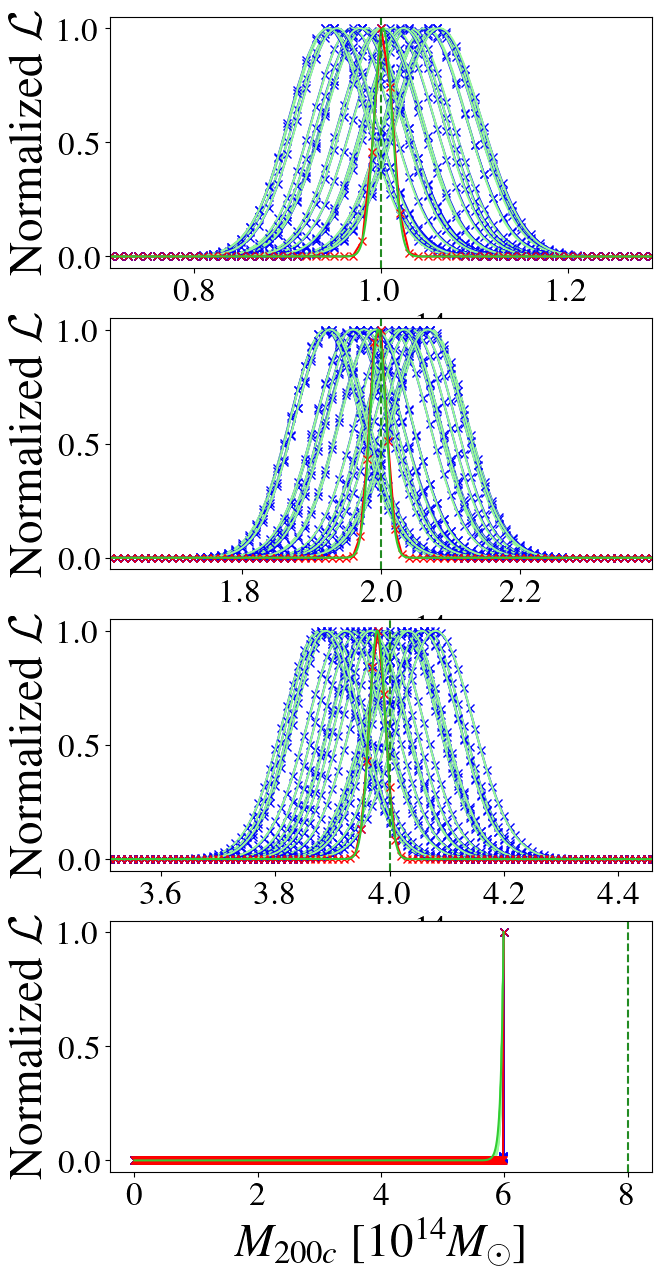

In [2]:
print('Checking likelhihood curves ...')
L_arr= np.load(save_loc_results+'likelihoods.npy', allow_pickle=True)
L_ip_arr = np.load(save_loc_results+'likelihoods_finer.npy', allow_pickle=True)
nber_runs = 20
s,e = 0, 20 
L_arr = [L_arr[0][s:e], L_arr[1][s:e], L_arr[2][s:e], L_arr[3][s:e]]
L_ip_arr = [L_ip_arr[0][s:e], L_ip_arr[1][s:e], L_ip_arr[2][s:e], L_ip_arr[3][s:e]]
comb_L_arr = []
comb_L_ip_arr = []
comb_median_mass_arr = []
comb_error_arr = []
for i in range(len(M_input_arr)):   
    x_comb, L_comb, median_value_comb, error_comb = stats.combined_likelihood(mass_int_arr[i], L_arr[i], normalize = True, finer_reso = False)
    print(median_value_comb, error_comb) 
    comb_L_arr.append(L_comb)
    M_ip_comb, L_ip_comb, median_value_comb_finer, error_comb_finer = stats.combined_likelihood(mass_int_arr[i], L_arr[i], normalize = True, finer_reso = True)
    print(median_value_comb_finer, error_comb_finer) 
    comb_L_ip_arr.append(L_ip_comb)
    comb_median_mass_arr.append(median_value_comb_finer)
    comb_error_arr.append(error_comb_finer)
combined_median_masses_results_file = ''
for i in range(len(comb_median_mass_arr)):
    combined_median_masses_results_file += "{0:11.2f}{1:>1}{2:5.2f}".format(comb_median_mass_arr[i], "+-", comb_error_arr[i]) + "\n"  
file = open(save_loc_results+'mass_results_wrong.txt',"w")
file.write(combined_median_masses_results_file)
file.close()


nber_runs_check = nber_runs
start_arr = [0, 0, 0, 0]
end_arr = [6000, 6000, 6000, 6000]
start_finer_arr = [0, 0, 0, 0]
end_finer_arr = [6000, 6000, 6000, 6000]
mass_int_finer_arr = [np.arange(min(mass_int_arr[0]),max(mass_int_arr[0]),0.001),
                      np.arange(min(mass_int_arr[1]),max(mass_int_arr[1]),0.001),
                      np.arange(min(mass_int_arr[2]),max(mass_int_arr[2]),0.001),
                      np.arange(min(mass_int_arr[3]),max(mass_int_arr[3]),0.001),]
                    
fig, axarr = plt.subplots(len(L_arr), 1, figsize=(7,15))
titles = ['1e14', '2e14', '414', '8e14']

for i in range(len(axarr)):
    for j in  range(nber_runs_check):
        axarr[i].plot(mass_int_arr[i][start_arr[i]:end_arr[i]], L_arr[i][j][start_arr[i]:end_arr[i]], ls = '-', marker = 'x', color = 'blue')
        axarr[i].plot(mass_int_finer_arr[i][start_finer_arr[i]:end_finer_arr[i]], L_ip_arr[i][j][start_finer_arr[i]:end_finer_arr[i]], ls = '-', marker = '', color = 'palegreen')   
    axarr[i].plot(mass_int_arr[i][start_arr[i]:end_arr[i]], comb_L_arr[i][start_arr[i]:end_arr[i]], ls = '-', marker = 'x', color = 'red')
    axarr[i].plot(mass_int_finer_arr[i][start_finer_arr[i]:end_finer_arr[i]], comb_L_ip_arr[i][start_finer_arr[i]:end_finer_arr[i]], ls = '-', marker = '', color = 'limegreen')
    axarr[i].axvline(M_input_arr[i]*1e-14, color = 'forestgreen', ls = '--')
    axarr[i].set_xlabel(r'$M_{200c} \ [10^{14}M_\odot]$', fontsize = fontsize)
    axarr[i].set_ylabel('Normalized '+r'$\mathcal{L}$', fontsize = fontsize)
    axarr[i].tick_params(labelsize = labelsize-6)
    if i == 0:
        axarr[i].set_xlim(0.71, 1.29)
    if i == 1:
        axarr[i].set_xlim(1.61, 2.39)
    if i == 2:
        axarr[i].set_xlim(3.51, 4.46)
plt.show()
fig.savefig(save_loc_results+'likelihoods_check_wrong.pdf', dpi = 200., bbox_inches = 'tight', pad_inches = 0.1)    


Plotting likelihood curves ...
1.0026361227197036 0.010857216448862228
1.0022615806949233 0.009582747421437443
1.9957311462265077 0.012434132818869736
1.9957743421250953 0.01167707547477459
3.978444771340499 0.01493766867220514
3.9785059027258223 0.014089609084777965
5.984999400576756 0.0034011906882049914
5.958030185957167 0.03702180441918479


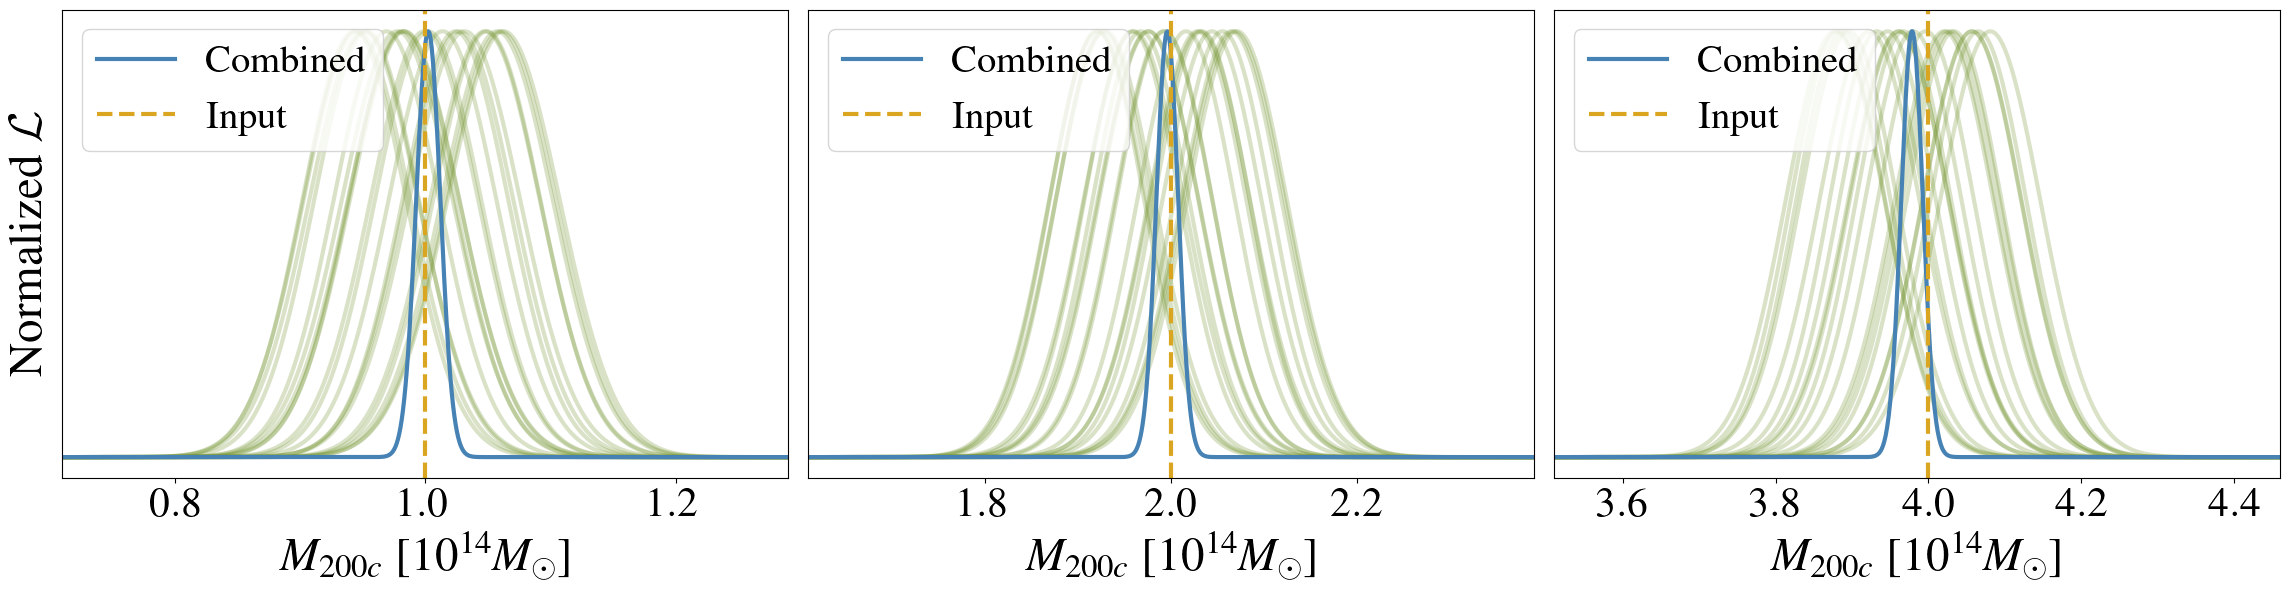

In [3]:
print('Plotting likelihood curves ...')
L_ip_arr = np.load(save_loc_results+'likelihoods_finer.npy', allow_pickle=True)
L_ip_arr = [L_ip_arr[0][s:e], L_ip_arr[1][s:e], L_ip_arr[2][s:e]]
comb_L_ip_arr = []
comb_median_mass_arr = []
comb_error_arr = []
for i in range(len(M_input_arr)):   
    x_comb, L_comb, median_value_comb, error_comb = stats.combined_likelihood(mass_int_arr[i], L_arr[i], normalize = True, finer_reso = False)
    print(median_value_comb, error_comb) 
    M_ip_comb, L_ip_comb, median_value_comb_finer, error_comb_finer = stats.combined_likelihood(mass_int_arr[i], L_arr[i], normalize = True, finer_reso = True)
    print(median_value_comb_finer, error_comb_finer) 
    comb_L_ip_arr.append(L_ip_comb)
    comb_median_mass_arr.append(median_value_comb_finer)
    comb_error_arr.append(error_comb_finer)
combined_median_masses_results_file = ''
for i in range(len(comb_median_mass_arr)):
    combined_median_masses_results_file += "{0:11.2f}{1:>1}{2:5.2f}".format(comb_median_mass_arr[i], "+-", comb_error_arr[i]) + "\n"  
file = open(save_loc_results+'mass_results.txt',"w")
file.write(combined_median_masses_results_file)
file.close()
#comb_L_arr = np.load(save_loc_results+'/comb_likelihoods.npy', allow_pickle=True)
#comb_L_ip_arr = np.load(save_loc_results+'/comb_likelihoods_finer.npy', allow_pickle=True)

#start_finer_arr = [200, 100, 39]
#end_finer_arr = [800, 900, 950]
start_finer_arr = [0, 0, 0]
end_finer_arr = [6000, 6000, 6000]
mass_int_finer_arr = [np.arange(min(mass_int_arr[0]),max(mass_int_arr[0]),0.001),
                      np.arange(min(mass_int_arr[1]),max(mass_int_arr[1]),0.001),
                      np.arange(min(mass_int_arr[2]),max(mass_int_arr[2]),0.001)]
                    
fig, axarr = plt.subplots(1, len(L_ip_arr), figsize=(23,6))

linewidth = 3.0
for i in range(len(axarr)):
    for j in  range(nber_runs):
        axarr[i].plot(mass_int_finer_arr[i][start_finer_arr[i]:end_finer_arr[i]], L_ip_arr[i][j][start_finer_arr[i]:end_finer_arr[i]], ls = '-', marker = '', color = color_arr[0], linewidth=linewidth, alpha = 0.25)   
    axarr[i].plot(mass_int_finer_arr[i][start_finer_arr[i]:end_finer_arr[i]], comb_L_ip_arr[i][start_finer_arr[i]:end_finer_arr[i]], ls = '-', marker = '', color = color_arr[1], linewidth=linewidth, label = 'Combined')
    axarr[i].axvline(M_input_arr[i]*1e-14, color = color_arr[2], ls = '--', label = 'Input', linewidth=linewidth)
    axarr[i].set_xlabel(r'$M_{200c} \ [10^{14}M_\odot]$', fontsize = fontsize)
    if i == 0:
        axarr[i].set_ylabel('Normalized '+r'$\mathcal{L}$', fontsize = fontsize)
    axarr[i].tick_params(labelsize = labelsize)
    axarr[i].legend(loc = 'upper left', prop={'size': labelsize-2})  
    axarr[i].axes.yaxis.set_ticks([])
    if i == 0:
        axarr[i].set_xlim(0.71, 1.29)
    if i == 1:
        axarr[i].set_xlim(1.61, 2.39)
    if i == 2:
        axarr[i].set_xlim(3.51, 4.46)
plt.tight_layout()
plt.show()
fig.savefig(save_loc_results+'pipeline_validation_wrong.pdf', dpi = 200., bbox_inches = 'tight', pad_inches = 0.1)   